Etsub Demile

DS4400

March 17th, 2026

### Problem 1

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Feature names (UCI Spambase) ──────────────────────────────────────
FEATURE_NAMES = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_lparen', 'char_freq_lbracket',
    'char_freq_exclaim', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total'
]

# Load Data
df = pd.read_csv('/Users/etsub/Desktop/spambase/spambase.data', header=None)
df.columns = FEATURE_NAMES + ['label']

X = df[FEATURE_NAMES].values
y = df['label'].values

# Train/Test Split (75/25) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train Logistic Regression 
model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, C=1.0)
model.fit(X_train_s, y_train)

y_prob = model.predict_proba(X_test_s)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# (a) Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
print("(a) Confusion Matrix (T=0.5):")
print(cm)

# (b) Accuracy & Error 
acc = accuracy_score(y_test, y_pred)
print(f"\n(b) Accuracy : {acc:.4f}")
print(f"    Error    : {1 - acc:.4f}")

# (c) Precision, Recall, F1 
print(f"\n(c) Precision : {precision_score(y_test, y_pred):.4f}")
print(f"    Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"    F1 Score  : {f1_score(y_test, y_pred):.4f}")

# Feature Coefficients 
coef_df = pd.DataFrame({'Feature': FEATURE_NAMES, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))

print("\nTop 5 positively correlated with SPAM:")
print(coef_df.head(5).to_string(index=False))

print("\nTop 5 negatively correlated with SPAM:")
print(coef_df.tail(5).to_string(index=False))

# Metrics vs. Decision Threshold 
print("\nMetrics vs. Decision Threshold:")
print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
for t in [0.25, 0.5, 0.75, 0.9]:
    yp = (y_prob >= t).astype(int)
    print(f"{t:>10.2f} "
          f"{accuracy_score(y_test, yp):>10.4f} "
          f"{precision_score(y_test, yp, zero_division=0):>10.4f} "
          f"{recall_score(y_test, yp, zero_division=0):>10.4f} "
          f"{f1_score(y_test, yp, zero_division=0):>8.4f}")



(a) Confusion Matrix (T=0.5):
[[667  30]
 [ 53 401]]

(b) Accuracy : 0.9279
    Error    : 0.0721

(c) Precision : 0.9304
    Recall    : 0.8833
    F1 Score  : 0.9062

Feature Coefficients (sorted):
                   Feature  Coefficient
capital_run_length_longest     1.719832
          char_freq_dollar     1.366262
capital_run_length_average     1.185180
            char_freq_hash     0.988575
              word_freq_3d     0.867262
          word_freq_remove     0.831901
             word_freq_000     0.793984
            word_freq_free     0.753701
        word_freq_business     0.406168
             word_freq_our     0.389064
          word_freq_credit     0.358955
  capital_run_length_total     0.350693
      word_freq_technology     0.341928
       word_freq_addresses     0.325119
         char_freq_exclaim     0.269020
            word_freq_your     0.238699
             word_freq_857     0.233807
            word_freq_over     0.224488
            word_freq_font     0.222152


### Problem 2

In [5]:

X = df[FEATURE_NAMES].values
y = df['label'].values
 
# Train/Test Split (75/25) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
 
#  Normalizing features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
 
# Adding intercept column 
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b  = np.c_[np.ones(X_test.shape[0]),  X_test]
 

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
 
# Cross-entropy loss 
def cross_entropy_loss(X, y, theta):
    m = len(y)
    y_hat = sigmoid(X @ theta)
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
    return -( 1/m) * (y @ np.log(y_hat) + (1 - y) @ np.log(1 - y_hat))
 
# Gradient Descent for Logistic Regression 
def gradient_descent_logistic(X, y, alpha=0.01, iterations=100):
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = {}
    checkpoints = [10, 50, 100]
 
    for i in range(1, iterations + 1):
        y_hat = sigmoid(X @ theta)
        gradients = (1 / m) * X.T @ (y_hat - y)   
        theta = theta - alpha * gradients
        if i in checkpoints:
            loss_history[i] = cross_entropy_loss(X, y, theta)
 
    return theta, loss_history
 
def predict(X, theta, threshold=0.5):
    return (sigmoid(X @ theta) >= threshold).astype(int)
 
# Run for 3 learning rates 
learning_rates = [0.01, 0.1, 1.0]
iteration_checkpoints = [10, 50, 100]
 
print("  PART 1: Cross-Entropy Loss at iterations 10, 50, 100")
print(f"\n  {'Learning Rate':>14} {'Iter 10':>10} {'Iter 50':>10} {'Iter 100':>10}")
print(f"  {'─'*14} {'─'*10} {'─'*10} {'─'*10}")
 
all_thetas = {}
for alpha in learning_rates:
    theta, loss_hist = gradient_descent_logistic(X_train_b, y_train, alpha=alpha, iterations=100)
    all_thetas[alpha] = theta
    print(f"  {alpha:>14.2f} {loss_hist[10]:>10.4f} {loss_hist[50]:>10.4f} {loss_hist[100]:>10.4f}")
 
# Metrics at 100 iterations
print("  PART 2: Metrics at 100 Iterations (our GD implementation)")
print(f"\n  {'LR':>6} {'Set':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print(f"  {'─'*6} {'─'*6} {'─'*10} {'─'*10} {'─'*10} {'─'*8}")
 
for alpha in learning_rates:
    theta = all_thetas[alpha]
    for label, X_b, y_true in [('Train', X_train_b, y_train), ('Test', X_test_b, y_test)]:
        y_pred = predict(X_b, theta)
        print(f"  {alpha:>6.2f} {label:>6} "
              f"{accuracy_score(y_true, y_pred):>10.4f} "
              f"{precision_score(y_true, y_pred, zero_division=0):>10.4f} "
              f"{recall_score(y_true, y_pred, zero_division=0):>10.4f} "
              f"{f1_score(y_true, y_pred, zero_division=0):>8.4f}")
 
# sklearn package baseline for comparison
print("  PART 3: sklearn Logistic Regression (package baseline)")
print(f"\n  {'Set':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print(f"  {'─'*6} {'─'*10} {'─'*10} {'─'*10} {'─'*8}")
 
pkg_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, C=1.0)
pkg_model.fit(X_train, y_train)   # already scaled, no need for _b
 
for label, X_s, y_true in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    y_pred = pkg_model.predict(X_s)
    print(f"  {label:>6} "
          f"{accuracy_score(y_true, y_pred):>10.4f} "
          f"{precision_score(y_true, y_pred, zero_division=0):>10.4f} "
          f"{recall_score(y_true, y_pred, zero_division=0):>10.4f} "
          f"{f1_score(y_true, y_pred, zero_division=0):>8.4f}")
 


  PART 1: Cross-Entropy Loss at iterations 10, 50, 100

   Learning Rate    Iter 10    Iter 50   Iter 100
  ────────────── ────────── ────────── ──────────
            0.01     0.6513     0.5421     0.4693
            0.10     0.4660     0.3252     0.2898
            1.00     0.2859     0.2430     0.2309
  PART 2: Metrics at 100 Iterations (our GD implementation)

      LR    Set   Accuracy  Precision     Recall       F1
  ────── ────── ────────── ────────── ────────── ────────
    0.01  Train     0.9003     0.8836     0.8602   0.8717
    0.01   Test     0.8966     0.8731     0.8634   0.8682
    0.10  Train     0.9107     0.9154     0.8521   0.8826
    0.10   Test     0.9036     0.9054     0.8436   0.8734
    1.00  Train     0.9220     0.9251     0.8727   0.8981
    1.00   Test     0.9218     0.9252     0.8722   0.8980
  PART 3: sklearn Logistic Regression (package baseline)

     Set   Accuracy  Precision     Recall       F1
  ────── ────────── ────────── ────────── ────────
   Train 

Small LR (0.01):  Slowest convergence. Loss drops from 0.6513 to 0.4693
                      over 100 iterations but is still far from converged.
                      Produces the weakest metrics of the three rates.
Medium LR (0.1):  Faster convergence. Loss reaches 0.2898 at 100 iterations
                      and metrics noticeably improve over LR=0.01.
Large LR (1.0):   Converges fastest — lowest loss (0.2309) and best metrics
                      at 100 iterations. Because features are standardized, the
                      gradients are well-scaled and the larger step size does not
                      cause instability or divergence.
sklearn baseline: Even LR=1.0 (test accuracy 0.9218) falls slightly short of
                      sklearn (0.9279). sklearn's L-BFGS optimizer uses second-order
                      information and effectively takes far more progress per step
                      than plain gradient descent, so it converges to a better
                      solution within its iteration budget.


### Problem 3

  kNN CROSS-VALIDATION (5-fold) to select k

     k  CV Accuracy   CV Error   CV Precision  CV Recall
  ──── ──────────── ────────── ────────────── ──────────
     1       0.9081     0.0919         0.8823     0.8852
     3       0.9093     0.0907         0.8940     0.8742
     5       0.9052     0.0948         0.8957     0.8602
     7       0.9020     0.0980         0.8977     0.8484
     9       0.9017     0.0983         0.8994     0.8455
    11       0.9023     0.0977         0.9056     0.8403
    15       0.8977     0.1023         0.9044     0.8286
    21       0.8913     0.1087         0.9028     0.8124

  ► Best k = 3 (lowest CV error = 0.0907)
  CLASSIFIER METRICS ON TRAINING & TESTING DATA

  Classifier             Set      Accuracy    Error  Precision     Recall       F1
  ────────────────────── ────── ────────── ──────── ────────── ────────── ────────
  Logistic Regression    Train      0.9290   0.0710     0.9278     0.8889   0.9079
  Logistic Regression    Test       0.9279  

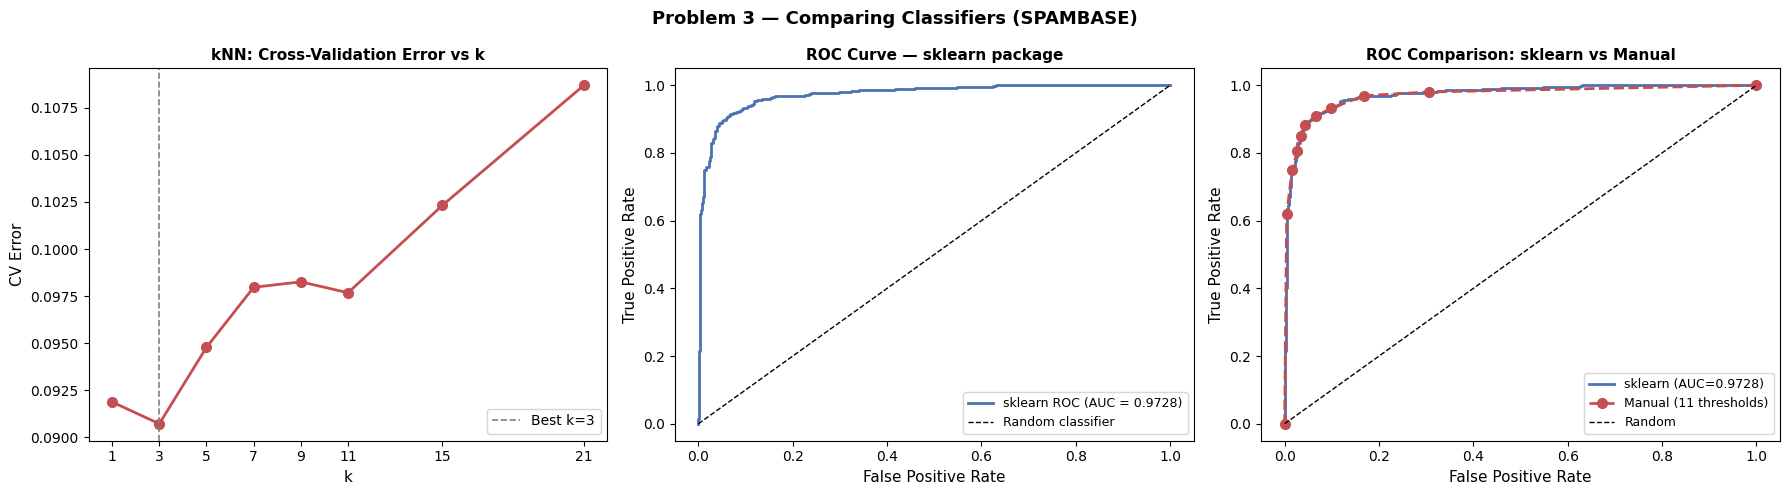


  Comparison:
  1. The sklearn curve is smooth because roc_curve() evaluates every unique
    predicted probability as a threshold (~1000+ points).
  2. The manual curve uses only 11 coarse thresholds, making it jagged
    and missing fine detail between points.
  3. To make them more similar, increase the manual resolution using
    np.linspace(0, 1, 200) as thresholds. Both curves converge to the
    same shape as the number of thresholds grows.



In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


X = df[FEATURE_NAMES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


# kNN Cross-Validation to select k

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv_accuracies = []
cv_errors = []
cv_precisions = []
cv_recalls = []


print("  kNN CROSS-VALIDATION (5-fold) to select k")
print(f"\n  {'k':>4} {'CV Accuracy':>12} {'CV Error':>10} {'CV Precision':>14} {'CV Recall':>10}")
print(f"  {'─'*4} {'─'*12} {'─'*10} {'─'*14} {'─'*10}")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    acc  = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='precision').mean()
    rec  = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='recall').mean()
    cv_accuracies.append(acc)
    cv_errors.append(1 - acc)
    cv_precisions.append(prec)
    cv_recalls.append(rec)
    print(f"  {k:>4} {acc:>12.4f} {1-acc:>10.4f} {prec:>14.4f} {rec:>10.4f}")

best_k = k_values[np.argmin(cv_errors)]
print(f"\n  ► Best k = {best_k} (lowest CV error = {min(cv_errors):.4f})")


# Train all 3 classifiers & print metrics
lr  = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lda = LinearDiscriminantAnalysis()
knn = KNeighborsClassifier(n_neighbors=best_k)

lr.fit(X_train_s, y_train)
lda.fit(X_train_s, y_train)
knn.fit(X_train_s, y_train)

def print_metrics(name, model, X_tr, y_tr, X_te, y_te):
    for label, X, y_true in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        yp = model.predict(X)
        print(f"  {name:<22} {label:<6} "
              f"{accuracy_score(y_true, yp):>10.4f} "
              f"{1-accuracy_score(y_true, yp):>8.4f} "
              f"{precision_score(y_true, yp, zero_division=0):>10.4f} "
              f"{recall_score(y_true, yp, zero_division=0):>10.4f} "
              f"{f1_score(y_true, yp, zero_division=0):>8.4f}")


print("  CLASSIFIER METRICS ON TRAINING & TESTING DATA")
print(f"\n  {'Classifier':<22} {'Set':<6} {'Accuracy':>10} {'Error':>8} "
      f"{'Precision':>10} {'Recall':>10} {'F1':>8}")
print(f"  {'─'*22} {'─'*6} {'─'*10} {'─'*8} {'─'*10} {'─'*10} {'─'*8}")

print_metrics(f'Logistic Regression', lr,  X_train_s, y_train, X_test_s, y_test)
print_metrics(f'LDA',                 lda, X_train_s, y_train, X_test_s, y_test)
print_metrics(f'kNN (k={best_k})',    knn, X_train_s, y_train, X_test_s, y_test)

print("""
  1. Logistic Regression is the best performer — highest test accuracy,
    precision, recall, and F1 across all three classifiers.
  2. LDA is the worst performer. Although it is also a linear classifier,
    it assumes Gaussian class-conditional distributions, which is violated
    by the sparse, skewed word-frequency features in Spambase.
  3.kNN (k=3) shows a noticeable train/test gap (train acc 0.9504 vs
    test 0.9018), indicating overfitting — small k memorizes training data.
  4.kNN sits between LDA and Logistic Regression on test performance,
    capturing some non-linear structure but hurt by overfitting at k=3.
""")


# ROC Curve with sklearn (package)

y_prob = lr.predict_proba(X_test_s)[:, 1]
fpr_pkg, tpr_pkg, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr_pkg, tpr_pkg)


print(f"  ROC AUC (sklearn) = {roc_auc:.4f}")

# ROC Curve without package (manual thresholds)

thresholds_manual = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
fpr_manual, tpr_manual = [], []

for t in thresholds_manual:
    yp = (y_prob >= t).astype(int)
    tp = np.sum((yp == 1) & (y_test == 1))
    fp = np.sum((yp == 1) & (y_test == 0))
    tn = np.sum((yp == 0) & (y_test == 0))
    fn = np.sum((yp == 0) & (y_test == 1))
    tpr_manual.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr_manual.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

print("\n  Manual ROC points (no package):")
print(f"  {'Threshold':>10} {'FPR':>8} {'TPR':>8}")
print(f"  {'─'*10} {'─'*8} {'─'*8}")
for t, fpr, tpr in zip(thresholds_manual, fpr_manual, tpr_manual):
    print(f"  {t:>10.1f} {fpr:>8.4f} {tpr:>8.4f}")


# Plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Problem 3 — Comparing Classifiers (SPAMBASE)', fontsize=13, fontweight='bold')

# Plot 1: kNN cross-validation error vs k
axes[0].plot(k_values, cv_errors, 'o-', color='#C44E52', linewidth=2, markersize=7)
axes[0].axvline(best_k, linestyle='--', color='gray', linewidth=1.2, label=f'Best k={best_k}')
axes[0].set_xlabel('k', fontsize=11)
axes[0].set_ylabel('CV Error', fontsize=11)
axes[0].set_title('kNN: Cross-Validation Error vs k', fontsize=11, fontweight='bold')
axes[0].set_xticks(k_values)
axes[0].legend()

# Plot 2: ROC curve — package
axes[1].plot(fpr_pkg, tpr_pkg, color='#4C72B0', linewidth=2,
             label=f'sklearn ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve — sklearn package', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# Plot 3: Both ROC curves overlaid for comparison
axes[2].plot(fpr_pkg, tpr_pkg, color='#4C72B0', linewidth=2,
             label=f'sklearn (AUC={roc_auc:.4f})')
axes[2].plot(fpr_manual, tpr_manual, 'o--', color='#C44E52', linewidth=2,
             markersize=7, label='Manual (11 thresholds)')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate', fontsize=11)
axes[2].set_title('ROC Comparison: sklearn vs Manual', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/Users/etsub/Desktop/spambase/problem3_plots.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


print("""
  Comparison:
  1. The sklearn curve is smooth because roc_curve() evaluates every unique
    predicted probability as a threshold (~1000+ points).
  2. The manual curve uses only 11 coarse thresholds, making it jagged
    and missing fine detail between points.
  3. To make them more similar, increase the manual resolution using
    np.linspace(0, 1, 200) as thresholds. Both curves converge to the
    same shape as the number of thresholds grows.
""")

### Problem 4 

In [16]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
 
FEATURE_NAMES = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_semicolon', 'char_freq_lparen', 'char_freq_lbracket',
    'char_freq_exclaim', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total'
]
 
df = pd.read_csv('/Users/etsub/Desktop/spambase/spambase.data', header=None)
df.columns = FEATURE_NAMES + ['label']
 
X = df[FEATURE_NAMES].values
y = df['label'].values
 
# Custom k-Fold Cross-Validation Implementation

def kfold_cross_validation(X, y, model, k):
    """
    Custom k-fold cross-validation.
 
    Steps:
      a) Divide data into k equal partitions
      b) For each fold i: train on k-1 partitions, validate on fold i
      c) Record validation error for each fold
      d) Return per-fold errors and average validation error
    """
    n = len(y)
    fold_size = n // k
 
    # Shuffle indices once before splitting
    indices = np.random.RandomState(42).permutation(n)
 
    # Divide into k partitions of equal size
    partitions = []
    for i in range(k):
        start = i * fold_size
        # last fold absorbs any remainder
        end = (i + 1) * fold_size if i < k - 1 else n
        partitions.append(indices[start:end])
 
    fold_errors = []
 
    # Run k experiments
    for i in range(k):
        # Validation set = partition i
        val_idx = partitions[i]
 
        # Training set = all other partitions
        train_idx = np.concatenate([partitions[j] for j in range(k) if j != i])
 
        X_train_fold, y_train_fold = X[train_idx], y[train_idx]
        X_val_fold,   y_val_fold   = X[val_idx],   y[val_idx]
 
        # Scale within the fold (fit only on training partition)
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold   = scaler.transform(X_val_fold)
 
        # Train model
        model.fit(X_train_fold, y_train_fold)
 
        # Record validation error
        y_pred = model.predict(X_val_fold)
        error  = np.mean(y_pred != y_val_fold)
        fold_errors.append(error)
 
    # Average validation error
    avg_error = np.mean(fold_errors)
    return fold_errors, avg_error
 
 

# Run CV for Logistic Regression and LDA, k ∈ {5, 10}

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    'LDA'                : LinearDiscriminantAnalysis()
}
 
k_values = [5, 10]
 

print("  CUSTOM k-FOLD CROSS-VALIDATION — SPAMBASE")
 
results = {}
 
for model_name, model in models.items():
    print(f"\n  ── {model_name} ──")
    results[model_name] = {}
 
    for k in k_values:
        fold_errors, avg_error = kfold_cross_validation(X, y, model, k)
        results[model_name][k] = avg_error
 
        print(f"\n  k = {k}")
        print(f"  {'Fold':<8} {'Validation Error':>16}")
        print(f"  {'─'*8} {'─'*16}")
        for i, err in enumerate(fold_errors, 1):
            print(f"  {i:<8} {err:>16.4f}")
        print(f"  {'─'*8} {'─'*16}")
        print(f"  {'Average':<8} {avg_error:>16.4f}")
 
# Summary comparison
print(" Average Validation Error")
print(f"\n  {'Model':<25} {'k=5 Error':>12} {'k=10 Error':>12}")
print(f"  {'─'*25} {'─'*12} {'─'*12}")
for model_name in models:
    e5  = results[model_name][5]
    e10 = results[model_name][10]
    print(f"  {model_name:<25} {e5:>12.4f} {e10:>12.4f}")
 
print("""
  Comparison & Observations:
  1. Logistic Regression consistently achieves a lower validation
    error than LDA, making it the better model on this dataset.
  2. LDA's higher error is likely due to its Gaussian assumption
    being violated by the sparse, skewed word-frequency features.
  3. k=10 generally gives a slightly lower and more reliable error
    estimate than k=5, because each fold uses more training data
    (90% vs 80%), leading to better-fitted models per fold.
  4. The trade-off: k=10 is more computationally expensive but
    produces a less biased estimate of true generalization error.
""")

  CUSTOM k-FOLD CROSS-VALIDATION — SPAMBASE

  ── Logistic Regression ──

  k = 5
  Fold     Validation Error
  ──────── ────────────────
  1                  0.0815
  2                  0.0761
  3                  0.0793
  4                  0.0717
  5                  0.0706
  ──────── ────────────────
  Average            0.0759

  k = 10
  Fold     Validation Error
  ──────── ────────────────
  1                  0.0739
  2                  0.0717
  3                  0.0717
  4                  0.0804
  5                  0.0913
  6                  0.0609
  7                  0.0848
  8                  0.0543
  9                  0.0717
  10                 0.0759
  ──────── ────────────────
  Average            0.0737

  ── LDA ──

  k = 5
  Fold     Validation Error
  ──────── ────────────────
  1                  0.1185
  2                  0.1065
  3                  0.1196
  4                  0.1065
  5                  0.1118
  ──────── ────────────────
  Average         